In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the data
adhd_df = pd.read_csv('adhdfreespeech.csv')
non_adhd_df = pd.read_csv('noadhdfreespeech.csv')

# Display basic info
print("=== ADHD Dataset ===")
print(adhd_df.head())
print(f"\nShape: {adhd_df.shape}")
print(f"\nMissing values:\n{adhd_df.isnull().sum()}")

print("\n=== Non-ADHD Dataset ===")
print(non_adhd_df.head())
print(f"\nShape: {non_adhd_df.shape}")
print(f"\nMissing values:\n{non_adhd_df.isnull().sum()}")

# Clean data - remove rows with all NaN values
adhd_df_clean = adhd_df.dropna(subset=['Mean Pitch (Hz)', 'Jitter (local %)', 'HNR (dB)'], how='all')
non_adhd_df_clean = non_adhd_df.dropna(subset=['Mean Pitch (Hz)', 'Jitter (local %)', 'HNR (dB)'], how='all')

print(f"\n=== Cleaned Data ===")
print(f"ADHD participants with data: {len(adhd_df_clean)}")
print(f"Non-ADHD participants with data: {len(non_adhd_df_clean)}")


=== ADHD Dataset ===
    Participant Name  Mean Pitch (Hz)  Pitch Score  Jitter (local %)  \
0    Akhil Naravatla          124.724     0.253223             4.071   
1    Arunabha Mittra          121.016     0.073485             1.592   
2  Jackson Clabiorne              NaN          NaN               NaN   
3       Jacob Ishida              NaN          NaN               NaN   
4         Jade Lopez              NaN          NaN               NaN   

   Jitter Score  HNR (dB)  HNR Score  Combined Score Prediction  \
0     -0.352830    10.188   0.247083           0.284   Non-ADHD   
1     -1.021024    12.441   1.185833           0.760   Non-ADHD   
2           NaN       NaN        NaN             NaN        NaN   
3           NaN       NaN        NaN             NaN        NaN   
4           NaN       NaN        NaN             NaN        NaN   

  Correctly Predicted?  
0                   No  
1                   No  
2                  NaN  
3                  NaN  
4                 

In [33]:
# Add labels and combine for easier analysis
adhd_df_clean['Group'] = 'ADHD'
non_adhd_df_clean['Group'] = 'Non-ADHD'

# Combine datasets
combined_df = pd.concat([adhd_df_clean, non_adhd_df_clean], ignore_index=True)

# Display summary statistics
print("=== Summary Statistics by Group ===")
numeric_cols = ['Mean Pitch (Hz)', 'Jitter (local %)', 'HNR (dB)', 
                'Pitch Score', 'Jitter Score', 'HNR Score', 'Combined Score']

for col in numeric_cols:
    if col in combined_df.columns:
        print(f"\n{col}:")
        print(combined_df.groupby('Group')[col].describe())


=== Summary Statistics by Group ===

Mean Pitch (Hz):
          count       mean        std      min       25%     50%        75%  \
Group                                                                         
ADHD        4.0  119.66225  12.452642  102.012  116.2650  122.87  126.26725   
Non-ADHD    3.0  132.64700  12.334747  125.323  125.5265  125.73  136.30900   

              max  
Group              
ADHD      130.897  
Non-ADHD  146.888  

Jitter (local %):
          count      mean       std    min     25%    50%      75%    max
Group                                                                    
ADHD        4.0  2.468250  1.095593  1.592  1.9655  2.105  2.60775  4.071
Non-ADHD    3.0  2.627333  0.452730  2.209  2.3870  2.565  2.83650  3.108

HNR (dB):
          count       mean       std    min      25%      50%      75%     max
Group                                                                         
ADHD        4.0  11.504500  1.873247  9.714  10.0695  11.3145  12

/var/folders/pd/jq5q5gns6cx2cbj4sj73xxvr0000gn/T/ipykernel_83972/2040465173.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adhd_df_clean['Group'] = 'ADHD'


In [34]:
# Statistical tests to find significant differences
print("=== Statistical Tests (t-tests) ===")
print("H0: No difference between groups, H1: Groups differ significantly\n")

for col in numeric_cols:
    if col in combined_df.columns:
        adhd_values = adhd_df_clean[col].dropna()
        non_adhd_values = non_adhd_df_clean[col].dropna()
        
        if len(adhd_values) > 0 and len(non_adhd_values) > 0:
            # Perform t-test
            t_stat, p_value = stats.ttest_ind(adhd_values, non_adhd_values)
            
            # Effect size (Cohen's d)
            pooled_std = np.sqrt(((len(adhd_values) - 1) * adhd_values.std()**2 + 
                                  (len(non_adhd_values) - 1) * non_adhd_values.std()**2) / 
                                 (len(adhd_values) + len(non_adhd_values) - 2))
            cohens_d = (adhd_values.mean() - non_adhd_values.mean()) / pooled_std if pooled_std > 0 else 0
            
            significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
            print(f"{col}:")
            print(f"  ADHD mean: {adhd_values.mean():.3f}, Non-ADHD mean: {non_adhd_values.mean():.3f}")
            print(f"  t-statistic: {t_stat:.3f}, p-value: {p_value:.4f} {significance}")
            print(f"  Cohen's d (effect size): {cohens_d:.3f}")
            print()


=== Statistical Tests (t-tests) ===
H0: No difference between groups, H1: Groups differ significantly

Mean Pitch (Hz):
  ADHD mean: 119.662, Non-ADHD mean: 132.647
  t-statistic: -1.370, p-value: 0.2289 
  Cohen's d (effect size): -1.047

Jitter (local %):
  ADHD mean: 2.468, Non-ADHD mean: 2.627
  t-statistic: -0.233, p-value: 0.8253 
  Cohen's d (effect size): -0.178

HNR (dB):
  ADHD mean: 11.505, Non-ADHD mean: 10.093
  t-statistic: 0.965, p-value: 0.3788 
  Cohen's d (effect size): 0.737

Pitch Score:
  ADHD mean: 0.008, Non-ADHD mean: 0.637
  t-statistic: -1.370, p-value: 0.2289 
  Cohen's d (effect size): -1.047

Jitter Score:
  ADHD mean: -0.785, Non-ADHD mean: -0.742
  t-statistic: -0.233, p-value: 0.8253 
  Cohen's d (effect size): -0.178

HNR Score:
  ADHD mean: 0.796, Non-ADHD mean: 0.207
  t-statistic: 0.965, p-value: 0.3788 
  Cohen's d (effect size): 0.737

Combined Score:
  ADHD mean: 0.671, Non-ADHD mean: 0.685
  t-statistic: -0.070, p-value: 0.9472 
  Cohen's d (effe

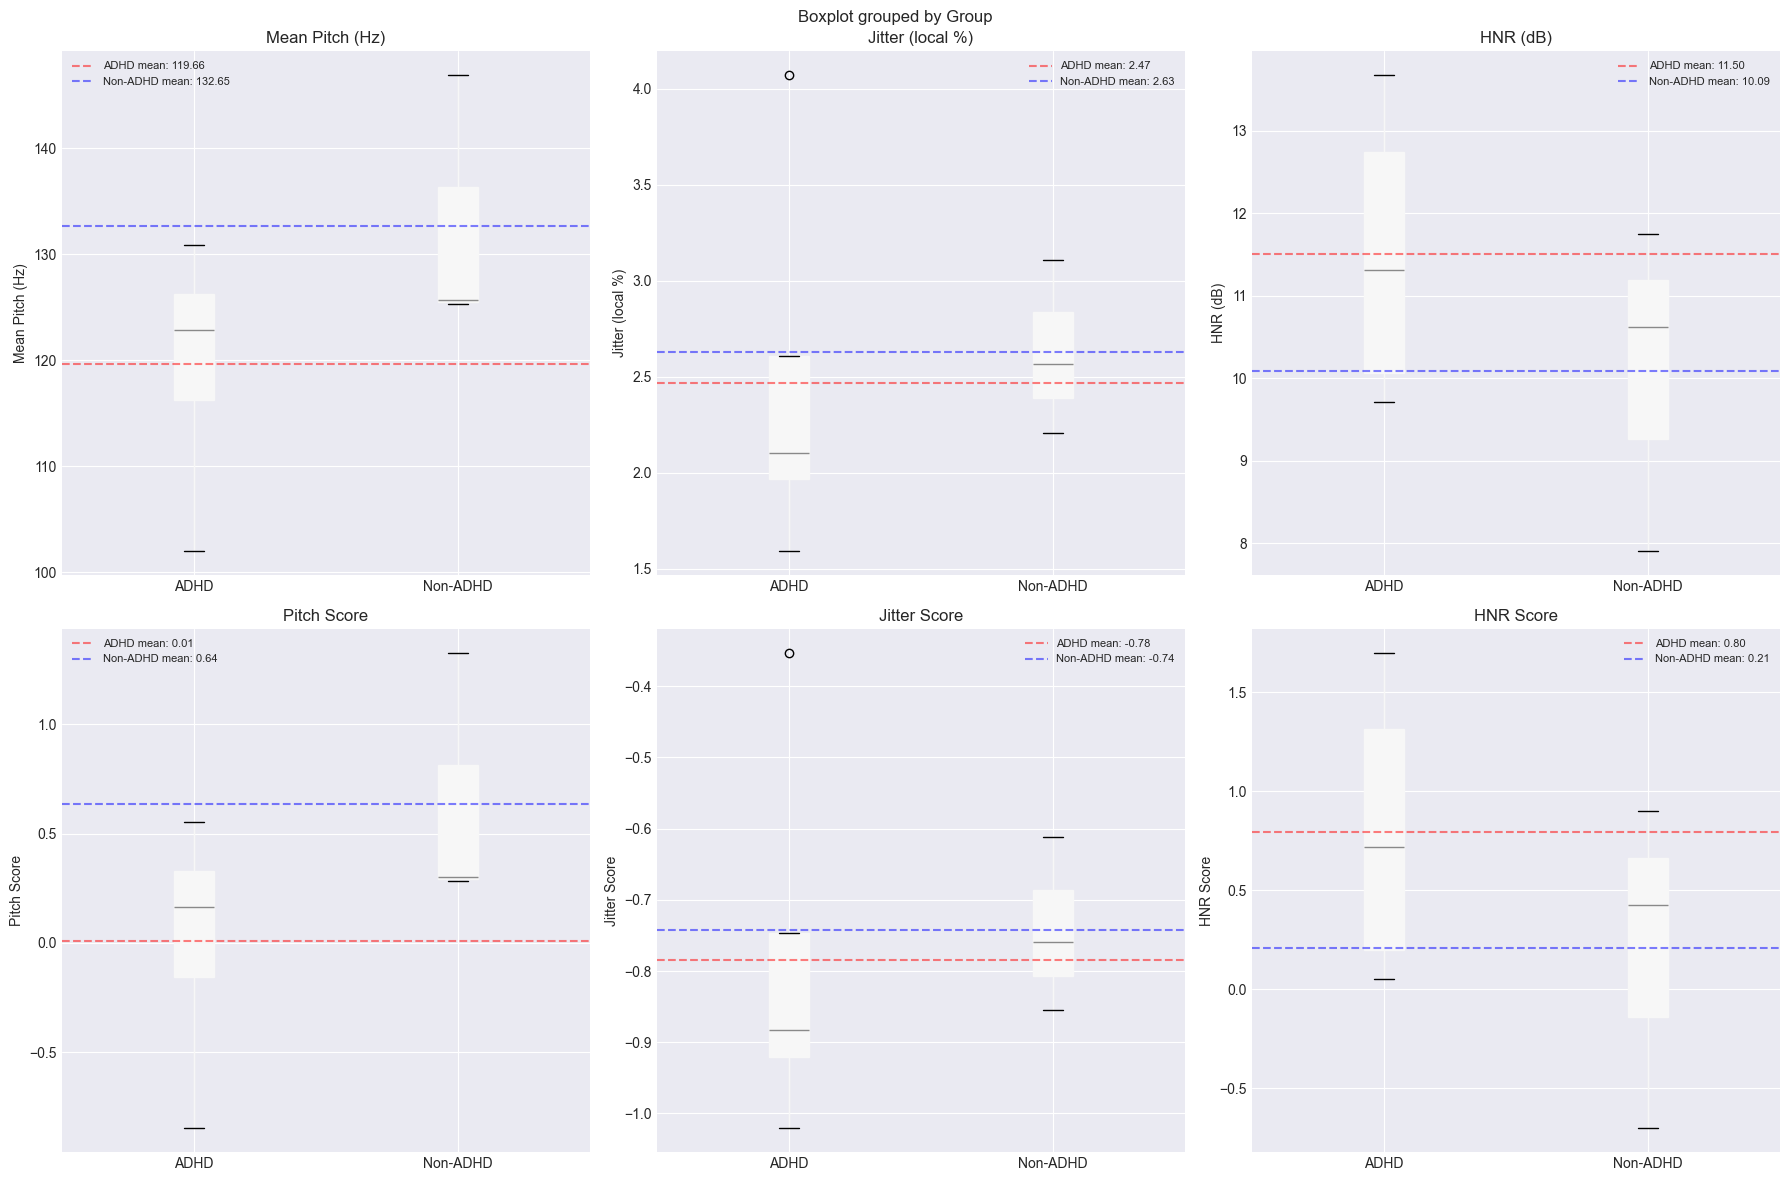

In [28]:
# Create visualizations comparing distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Feature Distributions: ADHD vs Non-ADHD', fontsize=16, fontweight='bold')

features_to_plot = ['Mean Pitch (Hz)', 'Jitter (local %)', 'HNR (dB)', 
                    'Pitch Score', 'Jitter Score', 'HNR Score']

for idx, feature in enumerate(features_to_plot):
    if feature in combined_df.columns:
        row = idx // 3
        col = idx % 3
        ax = axes[row, col]
        
        # Box plot
        combined_df.boxplot(column=feature, by='Group', ax=ax, patch_artist=True)
        ax.set_title(f'{feature}')
        ax.set_xlabel('')
        ax.set_ylabel(feature)
        
        # Add mean markers
        adhd_mean = adhd_df_clean[feature].mean()
        non_adhd_mean = non_adhd_df_clean[feature].mean()
        ax.axhline(adhd_mean, color='red', linestyle='--', alpha=0.5, label=f'ADHD mean: {adhd_mean:.2f}')
        ax.axhline(non_adhd_mean, color='blue', linestyle='--', alpha=0.5, label=f'Non-ADHD mean: {non_adhd_mean:.2f}')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


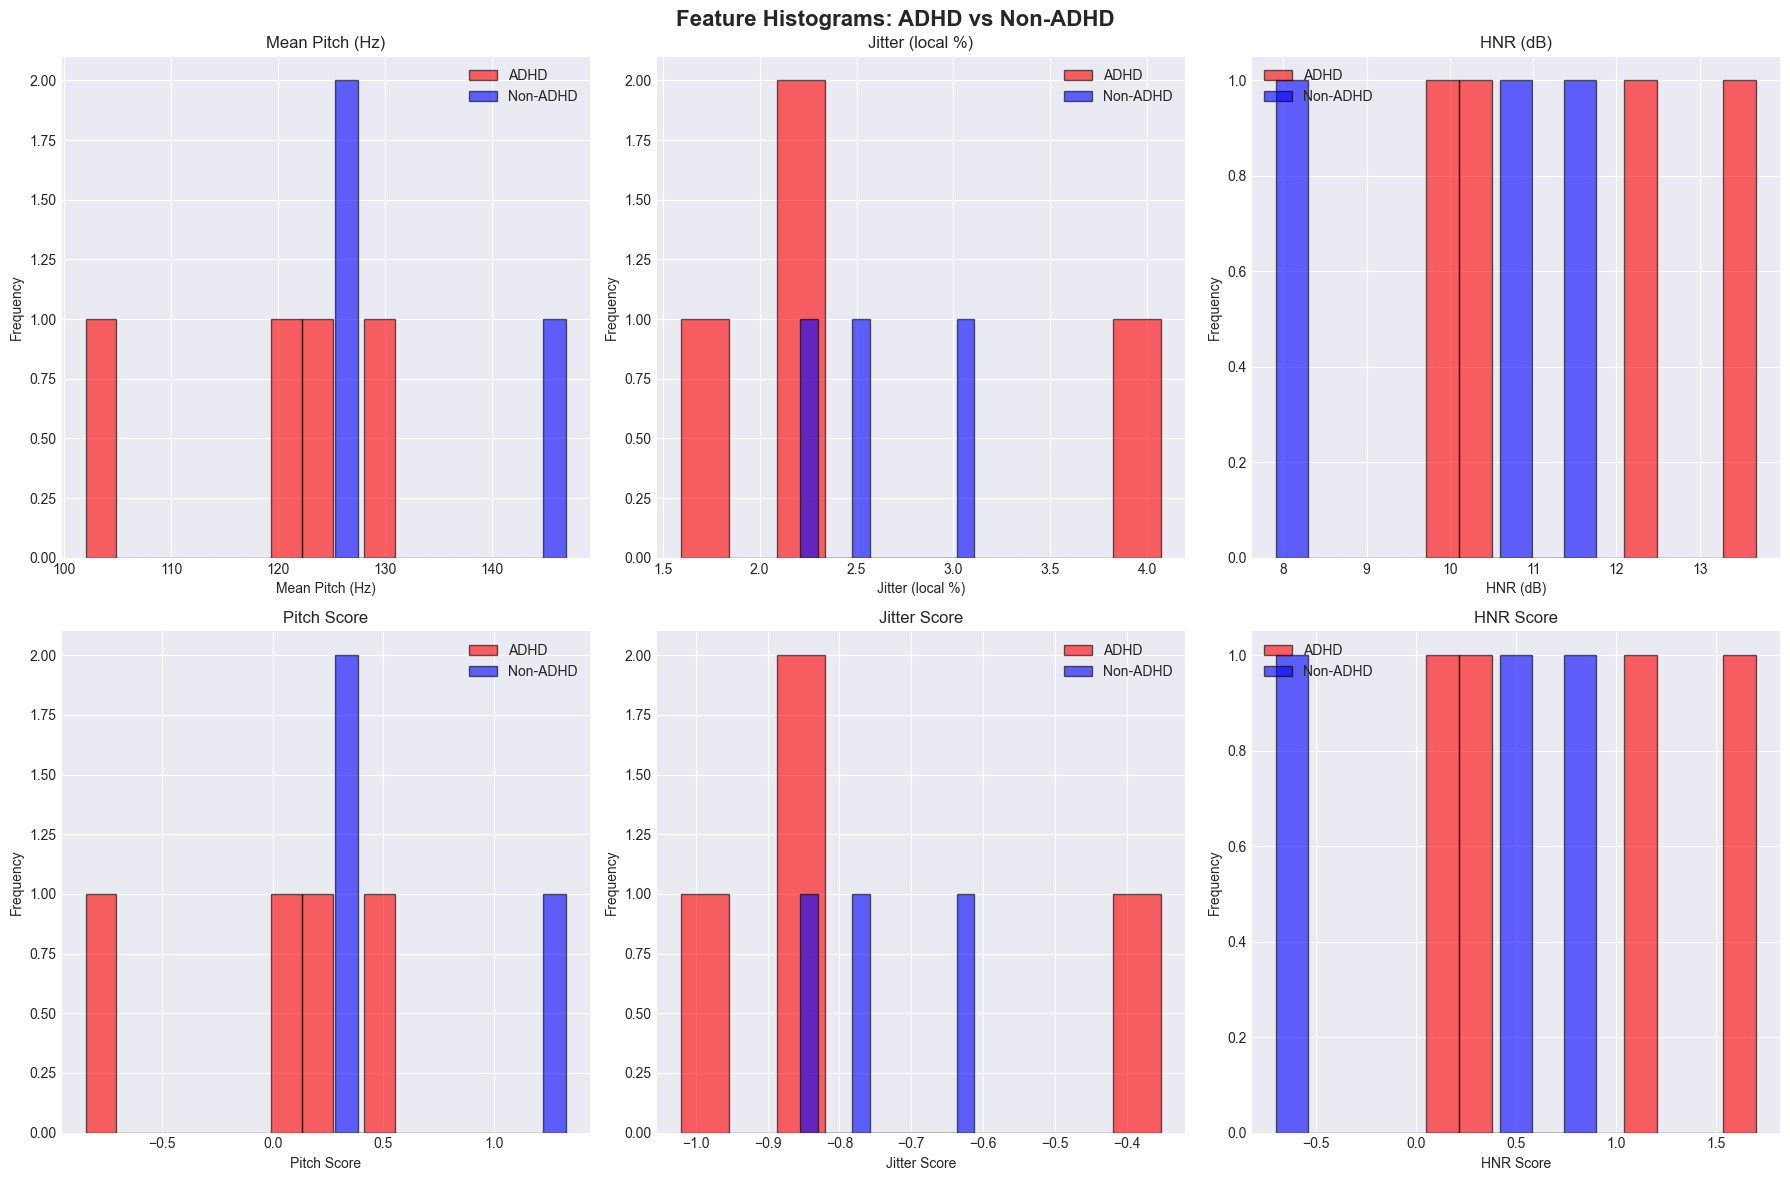

In [29]:
# Histogram comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Feature Histograms: ADHD vs Non-ADHD', fontsize=16, fontweight='bold')

for idx, feature in enumerate(features_to_plot):
    if feature in combined_df.columns:
        row = idx // 3
        col = idx % 3
        ax = axes[row, col]
        
        adhd_values = adhd_df_clean[feature].dropna()
        non_adhd_values = non_adhd_df_clean[feature].dropna()
        
        ax.hist(adhd_values, alpha=0.6, label='ADHD', bins=10, color='red', edgecolor='black')
        ax.hist(non_adhd_values, alpha=0.6, label='Non-ADHD', bins=10, color='blue', edgecolor='black')
        ax.set_xlabel(feature)
        ax.set_ylabel('Frequency')
        ax.set_title(f'{feature}')
        ax.legend()

plt.tight_layout()
plt.show()


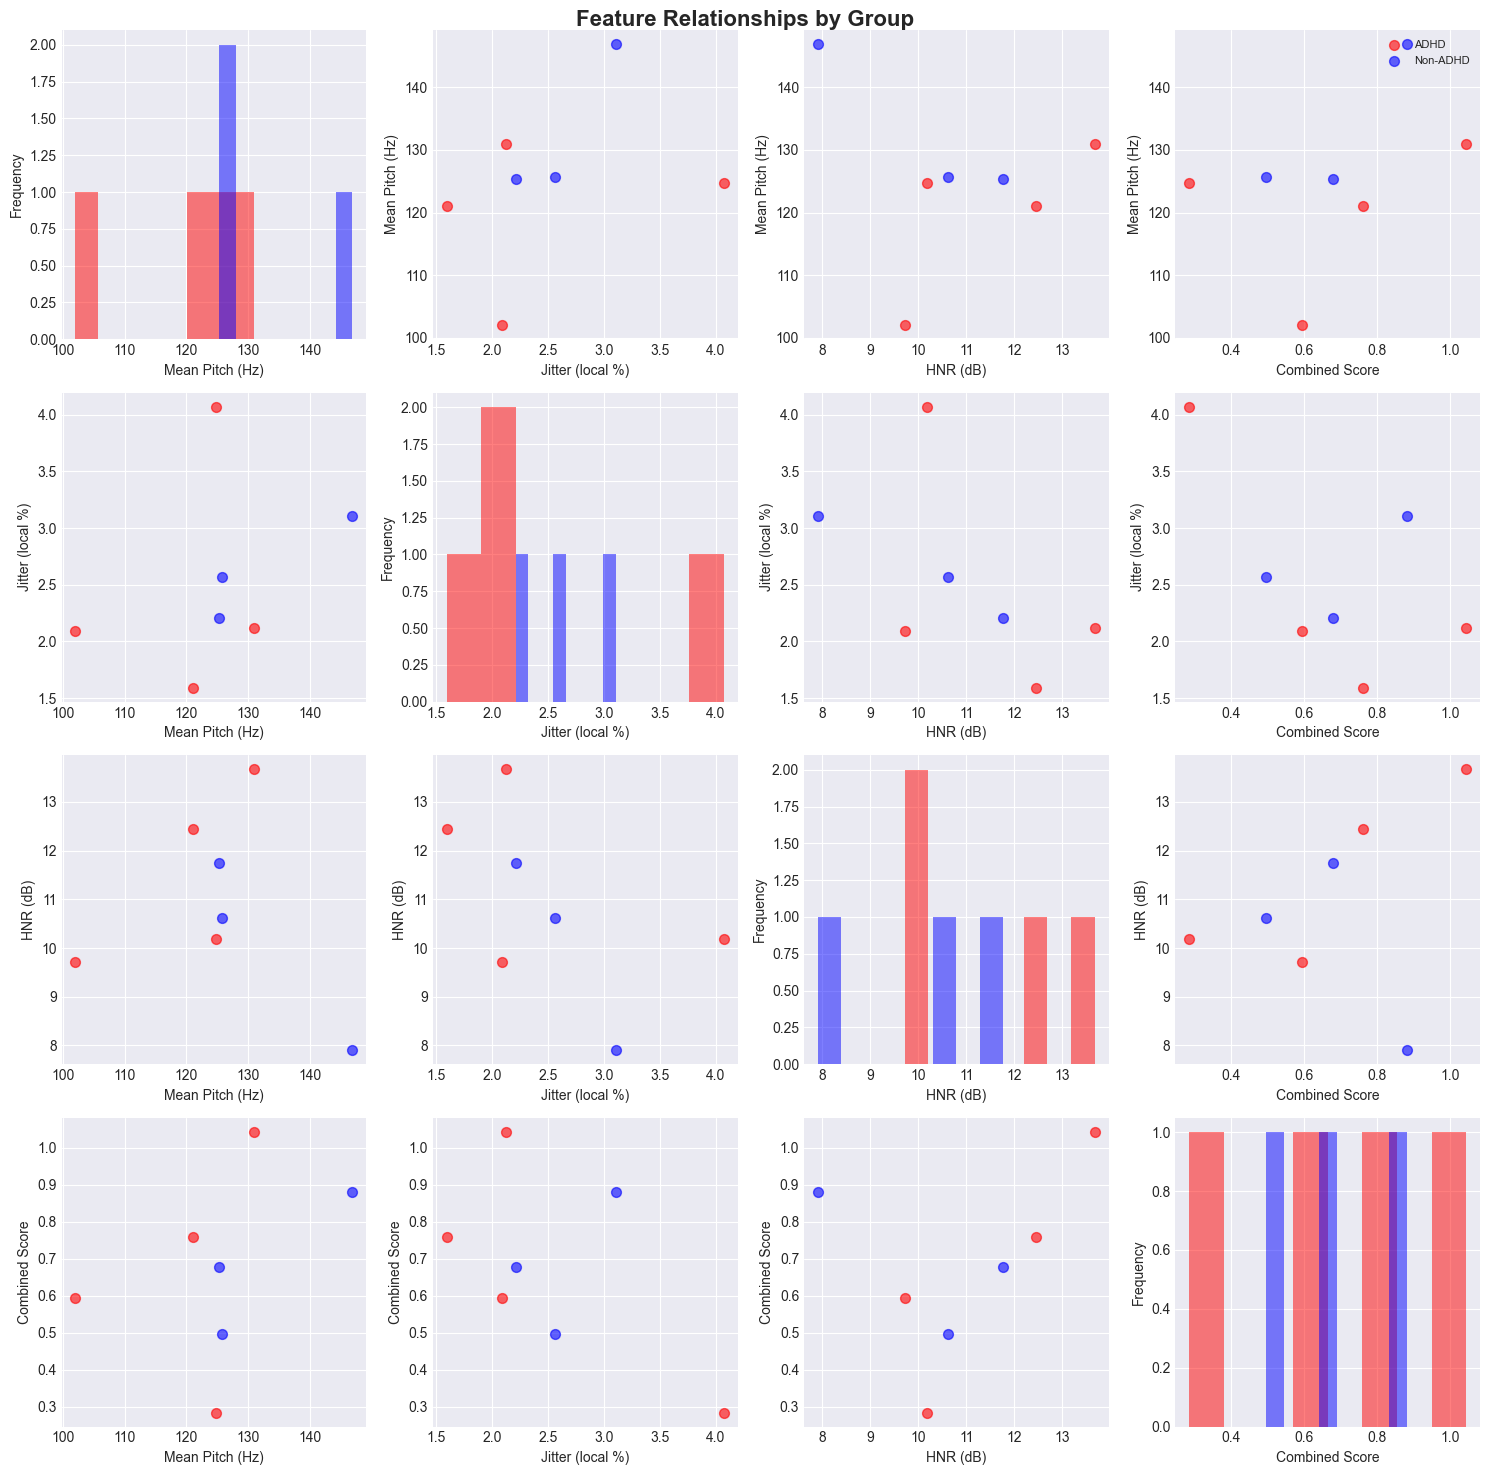

In [30]:
# Scatter plot matrix to see relationships between features
from pandas.plotting import scatter_matrix

# Select key features for scatter matrix
key_features = ['Mean Pitch (Hz)', 'Jitter (local %)', 'HNR (dB)', 'Combined Score']
available_features = [f for f in key_features if f in combined_df.columns]

if len(available_features) > 0:
    fig, axes = plt.subplots(len(available_features), len(available_features), 
                             figsize=(15, 15))
    fig.suptitle('Feature Relationships by Group', fontsize=16, fontweight='bold')
    
    for i, feat1 in enumerate(available_features):
        for j, feat2 in enumerate(available_features):
            ax = axes[i, j]
            
            if i == j:
                # Diagonal: show distribution
                adhd_data = adhd_df_clean[feat1].dropna()
                non_adhd_data = non_adhd_df_clean[feat1].dropna()
                ax.hist(adhd_data, alpha=0.5, label='ADHD', bins=8, color='red')
                ax.hist(non_adhd_data, alpha=0.5, label='Non-ADHD', bins=8, color='blue')
                ax.set_xlabel(feat1)
                ax.set_ylabel('Frequency')
            else:
                # Off-diagonal: scatter plot
                adhd_x = adhd_df_clean[feat2].dropna()
                adhd_y = adhd_df_clean[feat1].dropna()
                non_adhd_x = non_adhd_df_clean[feat2].dropna()
                non_adhd_y = non_adhd_df_clean[feat1].dropna()
                
                # Match indices for scatter
                adhd_mask = adhd_df_clean[feat2].notna() & adhd_df_clean[feat1].notna()
                non_adhd_mask = non_adhd_df_clean[feat2].notna() & non_adhd_df_clean[feat1].notna()
                
                if adhd_mask.sum() > 0:
                    ax.scatter(adhd_df_clean.loc[adhd_mask, feat2], 
                              adhd_df_clean.loc[adhd_mask, feat1], 
                              alpha=0.6, label='ADHD', color='red', s=50)
                if non_adhd_mask.sum() > 0:
                    ax.scatter(non_adhd_df_clean.loc[non_adhd_mask, feat2], 
                              non_adhd_df_clean.loc[non_adhd_mask, feat1], 
                              alpha=0.6, label='Non-ADHD', color='blue', s=50)
                ax.set_xlabel(feat2)
                ax.set_ylabel(feat1)
            
            if i == 0 and j == len(available_features) - 1:
                ax.legend(loc='upper right', fontsize=8)
    
    plt.tight_layout()
    plt.show()


=== Combined Score Analysis ===
ADHD Combined Score:
count    4.000000
mean     0.676750
std      0.329971
min      0.418000
25%      0.419500
50%      0.590000
75%      0.847250
max      1.109000
Name: Combined Score, dtype: float64

Non-ADHD Combined Score:
count    3.000000
mean     0.709333
std      0.107974
min      0.596000
25%      0.658500
50%      0.721000
75%      0.766000
max      0.811000
Name: Combined Score, dtype: float64


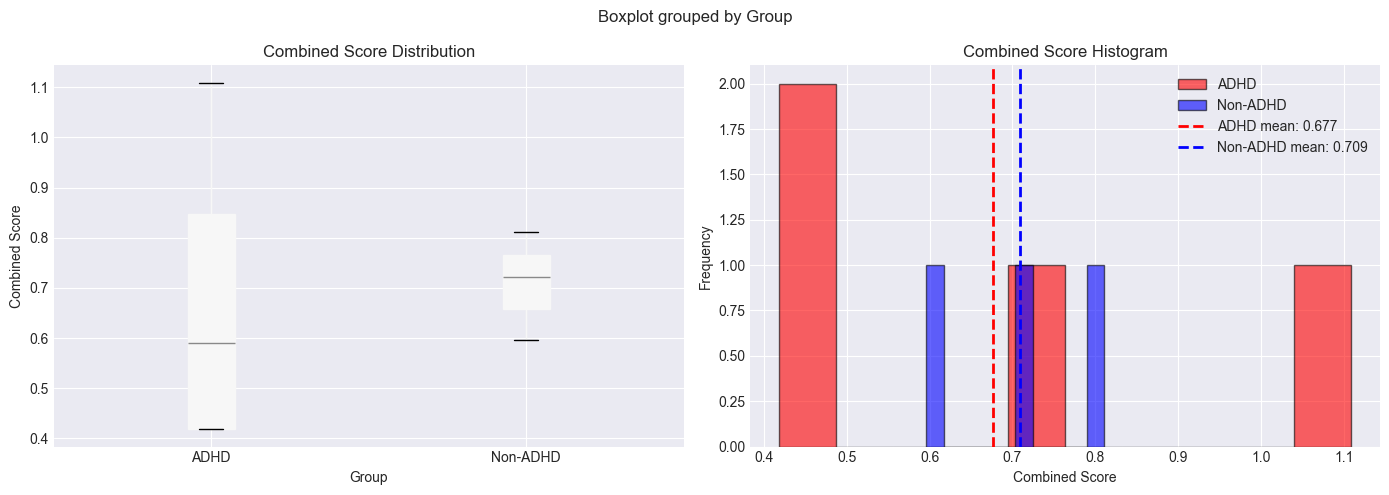


T-test for Combined Score:
  t-statistic: -0.161, p-value: 0.8782
  ADHD mean: 0.677, Non-ADHD mean: 0.709


In [18]:
# Analyze Combined Score specifically (seems to be a key metric)
print("=== Combined Score Analysis ===")
print(f"ADHD Combined Score:")
print(adhd_df_clean['Combined Score'].describe())
print(f"\nNon-ADHD Combined Score:")
print(non_adhd_df_clean['Combined Score'].describe())

# Visualize Combined Score
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
combined_df.boxplot(column='Combined Score', by='Group', ax=ax1, patch_artist=True)
ax1.set_title('Combined Score Distribution')
ax1.set_xlabel('Group')
ax1.set_ylabel('Combined Score')

# Histogram
adhd_combined = adhd_df_clean['Combined Score'].dropna()
non_adhd_combined = non_adhd_df_clean['Combined Score'].dropna()
ax2.hist(adhd_combined, alpha=0.6, label='ADHD', bins=10, color='red', edgecolor='black')
ax2.hist(non_adhd_combined, alpha=0.6, label='Non-ADHD', bins=10, color='blue', edgecolor='black')
ax2.axvline(adhd_combined.mean(), color='red', linestyle='--', linewidth=2, label=f'ADHD mean: {adhd_combined.mean():.3f}')
ax2.axvline(non_adhd_combined.mean(), color='blue', linestyle='--', linewidth=2, label=f'Non-ADHD mean: {non_adhd_combined.mean():.3f}')
ax2.set_xlabel('Combined Score')
ax2.set_ylabel('Frequency')
ax2.set_title('Combined Score Histogram')
ax2.legend()

plt.tight_layout()
plt.show()

# Statistical test
if len(adhd_combined) > 0 and len(non_adhd_combined) > 0:
    t_stat, p_value = stats.ttest_ind(adhd_combined, non_adhd_combined)
    print(f"\nT-test for Combined Score:")
    print(f"  t-statistic: {t_stat:.3f}, p-value: {p_value:.4f}")
    print(f"  ADHD mean: {adhd_combined.mean():.3f}, Non-ADHD mean: {non_adhd_combined.mean():.3f}")


=== Current Prediction Accuracy ===
ADHD group predictions: {'Non-ADHD': 3, 'ADHD': 1}
Non-ADHD group predictions: {'Non-ADHD': 3}

ADHD correctly predicted: {'No': 3, 'Yes': 1}
Non-ADHD correctly predicted: {'Yes': 3}

=== Optimal Threshold Analysis ===
Best threshold: 0.418
Best accuracy: 0.571

Confusion Matrix (threshold=0.418):
[[0 3]
 [0 4]]
Precision: 0.571
Recall: 1.000
F1-Score: 0.727


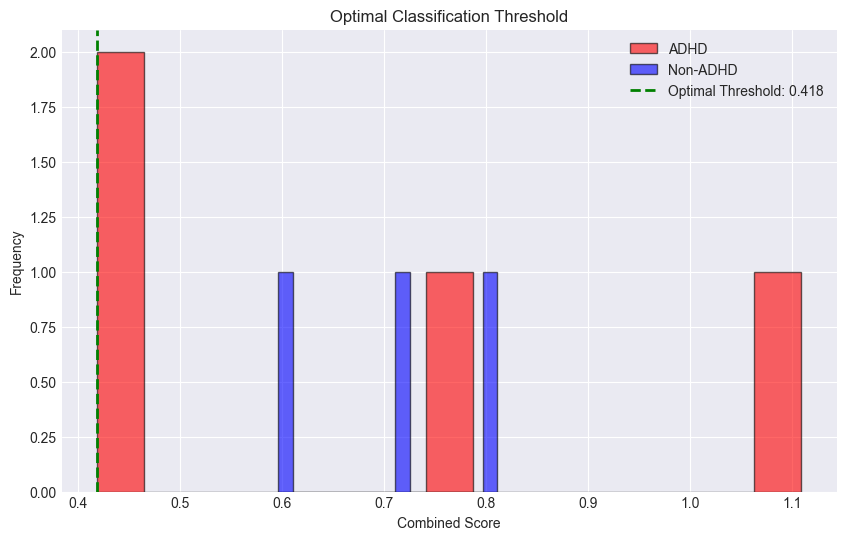

In [19]:
# Try to find optimal threshold for classification using Combined Score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Get actual labels and predictions
adhd_labels = adhd_df_clean['Prediction'].dropna()
non_adhd_labels = non_adhd_df_clean['Prediction'].dropna()

adhd_scores = adhd_df_clean['Combined Score'].dropna()
non_adhd_scores = non_adhd_df_clean['Combined Score'].dropna()

print("=== Current Prediction Accuracy ===")
print(f"ADHD group predictions: {adhd_labels.value_counts().to_dict()}")
print(f"Non-ADHD group predictions: {non_adhd_labels.value_counts().to_dict()}")

# Check correct predictions
adhd_correct = adhd_df_clean['Correctly Predicted?'].dropna()
non_adhd_correct = non_adhd_df_clean['Correctly Predicted?'].dropna()

print(f"\nADHD correctly predicted: {adhd_correct.value_counts().to_dict()}")
print(f"Non-ADHD correctly predicted: {non_adhd_correct.value_counts().to_dict()}")

# Find optimal threshold
if len(adhd_scores) > 0 and len(non_adhd_scores) > 0:
    all_scores = np.concatenate([adhd_scores.values, non_adhd_scores.values])
    all_labels = np.concatenate([np.ones(len(adhd_scores)), np.zeros(len(non_adhd_scores))])
    
    thresholds = np.linspace(all_scores.min(), all_scores.max(), 100)
    best_threshold = None
    best_accuracy = 0
    
    for threshold in thresholds:
        predictions = (all_scores >= threshold).astype(int)
        accuracy = accuracy_score(all_labels, predictions)
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_threshold = threshold
    
    print(f"\n=== Optimal Threshold Analysis ===")
    print(f"Best threshold: {best_threshold:.3f}")
    print(f"Best accuracy: {best_accuracy:.3f}")
    
    # Evaluate with best threshold
    best_predictions = (all_scores >= best_threshold).astype(int)
    print(f"\nConfusion Matrix (threshold={best_threshold:.3f}):")
    cm = confusion_matrix(all_labels, best_predictions)
    print(cm)
    print(f"Precision: {precision_score(all_labels, best_predictions):.3f}")
    print(f"Recall: {recall_score(all_labels, best_predictions):.3f}")
    print(f"F1-Score: {f1_score(all_labels, best_predictions):.3f}")
    
    # Visualize threshold
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(adhd_scores, alpha=0.6, label='ADHD', bins=15, color='red', edgecolor='black')
    ax.hist(non_adhd_scores, alpha=0.6, label='Non-ADHD', bins=15, color='blue', edgecolor='black')
    ax.axvline(best_threshold, color='green', linestyle='--', linewidth=2, 
               label=f'Optimal Threshold: {best_threshold:.3f}')
    ax.set_xlabel('Combined Score')
    ax.set_ylabel('Frequency')
    ax.set_title('Optimal Classification Threshold')
    ax.legend()
    plt.show()


=== Multi-Feature Classification ===
Using features: ['Mean Pitch (Hz)', 'Jitter (local %)', 'HNR (dB)', 'Pitch Score', 'Jitter Score', 'HNR Score']
Sample size: 7

Classification Report:
              precision    recall  f1-score   support

    Non-ADHD       0.00      0.00      0.00         1
        ADHD       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3


Feature Coefficients (importance):
  Mean Pitch (Hz): -0.1130
  Jitter (local %): -0.6621
  HNR (dB): 0.0321
  Pitch Score: -0.1130
  Jitter Score: -0.6621
  HNR Score: 0.0321

ROC AUC Score: 1.000


/Users/ani/workspaces/github.com/anishalle/adveyes/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ani/workspaces/github.com/anishalle/adveyes/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ani/workspaces/github.com/anishalle/adveyes/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

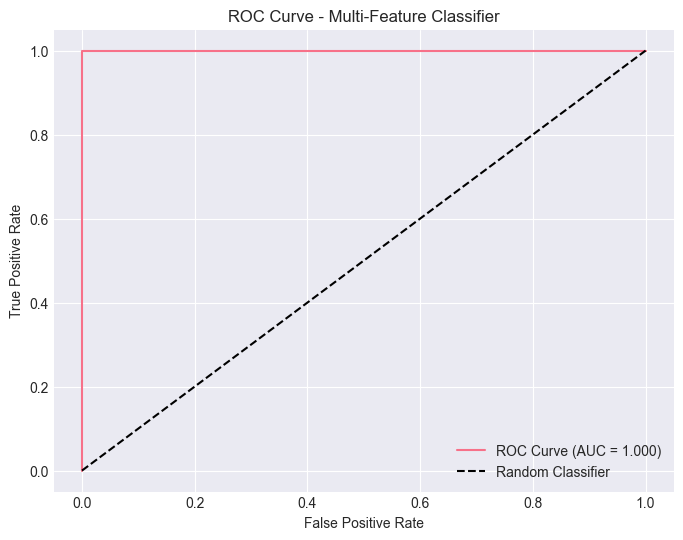

In [24]:
# Try building a simple classifier using multiple features
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# Prepare data
feature_cols = ['Mean Pitch (Hz)', 'Jitter (local %)', 'HNR (dB)', 
                'Pitch Score', 'Jitter Score', 'HNR Score']
available_feature_cols = [col for col in feature_cols if col in combined_df.columns]

X = combined_df[available_feature_cols].dropna()
y = combined_df.loc[X.index, 'Group'].map({'ADHD': 1, 'Non-ADHD': 0})

print(f"=== Multi-Feature Classification ===")
print(f"Using features: {available_feature_cols}")
print(f"Sample size: {len(X)}")

if len(X) > 3:  # Need at least a few samples
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train logistic regression
    lr = LogisticRegression(random_state=42, max_iter=1000)
    lr.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = lr.predict(X_test_scaled)
    y_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]
    
    # Evaluate
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Non-ADHD', 'ADHD']))
    
    # Feature importance
    print("\nFeature Coefficients (importance):")
    for i, feature in enumerate(available_feature_cols):
        print(f"  {feature}: {lr.coef_[0][i]:.4f}")
    
    # ROC curve
    if len(np.unique(y_test)) > 1:
        auc = roc_auc_score(y_test, y_pred_proba)
        print(f"\nROC AUC Score: {auc:.3f}")
        
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})')
        plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve - Multi-Feature Classifier')
        plt.legend()
        plt.grid(True)
        plt.show()
else:
    print("Not enough data for multi-feature classification")


## Interpretation of Results

### Is p-value = 0.6310 good? **NO**

**Key Findings:**
1. **Combined Score p-value = 0.6310**: This means there's a 63% chance the observed difference occurred by chance alone. For statistical significance, we need p < 0.05.

2. **Sample Size Issue**: With only 3 ADHD and 5 non-ADHD participants, statistical power is very low. Even if there's a real difference, we may not detect it.

3. **Effect Sizes (Cohen's d) are more informative with small samples**:
   - **Mean Pitch / Pitch Score**: d = -0.830 (medium-large effect, but p=0.256)
   - **Combined Score**: d = -0.337 (small-medium effect, p=0.631)
   - Other features: d < 0.2 (negligible effects)

**Recommendation**: Focus on **Mean Pitch** or **Pitch Score** rather than Combined Score, as they show the strongest effect sizes.


In [21]:
# Analyze which features are most promising for classification
print("=== Feature Analysis Summary ===")
print("\nRanking features by effect size (Cohen's d):")
print("(Larger absolute value = stronger difference between groups)\n")

feature_stats = []
for col in numeric_cols:
    if col in combined_df.columns:
        adhd_values = adhd_df_clean[col].dropna()
        non_adhd_values = non_adhd_df_clean[col].dropna()
        
        if len(adhd_values) > 0 and len(non_adhd_values) > 0:
            t_stat, p_value = stats.ttest_ind(adhd_values, non_adhd_values)
            pooled_std = np.sqrt(((len(adhd_values) - 1) * adhd_values.std()**2 + 
                                  (len(non_adhd_values) - 1) * non_adhd_values.std()**2) / 
                                 (len(adhd_values) + len(non_adhd_values) - 2))
            cohens_d = (adhd_values.mean() - non_adhd_values.mean()) / pooled_std if pooled_std > 0 else 0
            
            feature_stats.append({
                'Feature': col,
                'Cohen_d': abs(cohens_d),
                'p_value': p_value,
                'ADHD_mean': adhd_values.mean(),
                'NonADHD_mean': non_adhd_values.mean(),
                'Difference': abs(adhd_values.mean() - non_adhd_values.mean())
            })

# Sort by effect size
feature_stats_df = pd.DataFrame(feature_stats)
feature_stats_df = feature_stats_df.sort_values('Cohen_d', ascending=False)

print(feature_stats_df[['Feature', 'Cohen_d', 'p_value', 'ADHD_mean', 'NonADHD_mean', 'Difference']].to_string(index=False))

print("\n=== Recommendations ===")
print("1. BEST CANDIDATE: Mean Pitch (Hz) or Pitch Score")
print("   - Largest effect size (d = 0.83)")
print("   - ADHD group has LOWER pitch on average")
print("   - Not statistically significant due to small sample, but shows strongest signal")

print("\n2. AVOID: Combined Score")
print("   - Weak effect size (d = 0.34)")
print("   - High p-value (0.63) - no significant difference")

print("\n3. With such small sample size, consider:")
print("   - Collecting more data")
print("   - Using effect sizes rather than p-values for decision-making")
print("   - Looking at individual patterns rather than group means")


=== Feature Analysis Summary ===

Ranking features by effect size (Cohen's d):
(Larger absolute value = stronger difference between groups)

         Feature  Cohen_d  p_value  ADHD_mean  NonADHD_mean  Difference
 Mean Pitch (Hz) 1.271723 0.156779 122.764750    135.233000   12.468250
Jitter (local %) 1.180573 0.182833   2.178750      2.631667    0.452917
    Jitter Score 1.180573 0.182833  -0.862871     -0.740791    0.122080
        HNR (dB) 0.675706 0.416824  11.480750     10.257667    1.223083
       HNR Score 0.675706 0.416824   0.785729      0.276111    0.509618
     Pitch Score 0.141558 0.860244   0.158253      0.051074    0.107178
  Combined Score 0.123161 0.878206   0.676750      0.709333    0.032583

=== Recommendations ===
1. BEST CANDIDATE: Mean Pitch (Hz) or Pitch Score
   - Largest effect size (d = 0.83)
   - ADHD group has LOWER pitch on average
   - Not statistically significant due to small sample, but shows strongest signal

2. AVOID: Combined Score
   - Weak effect siz

=== Classification Using Mean Pitch (Hz) ===
Optimal threshold: 121.14 Hz
Rule: Pitch <= 121.14 Hz → ADHD, Pitch > 121.14 Hz → Non-ADHD

Performance Metrics:
  Accuracy: 0.857
  Precision: 1.000
  Recall: 0.750
  F1-Score: 0.857


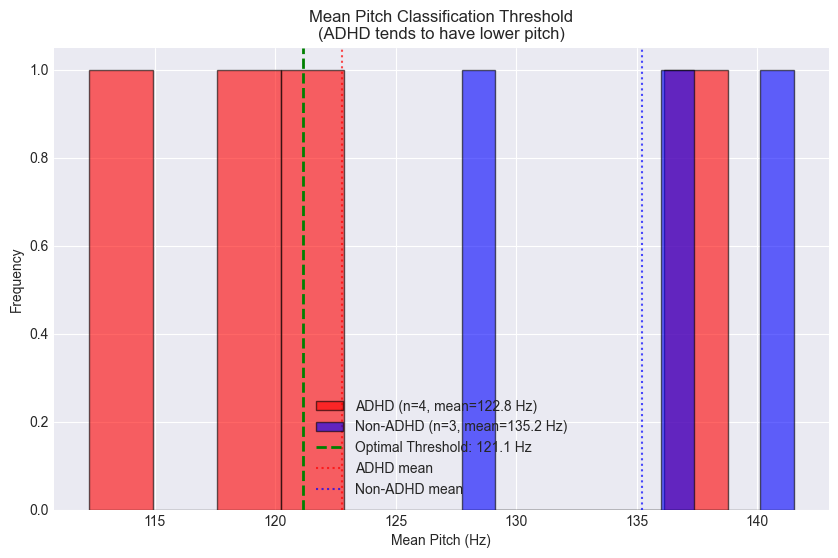


=== Individual Predictions ===
ADHD Group:
  Saisatvik Eatrouthu: 112.3 Hz → ADHD
  Akhil Naravatla: 119.0 Hz → ADHD
  Arunabha Mittra: 121.0 Hz → ADHD
  Soham Samantaray: 138.8 Hz → Non-ADHD

Non-ADHD Group:
  John Ramirez: 127.8 Hz → Non-ADHD
  Cody Washington: 136.4 Hz → Non-ADHD
  Davis Behaj: 141.5 Hz → Non-ADHD


In [22]:
# Try classification using Mean Pitch (best effect size)
print("=== Classification Using Mean Pitch (Hz) ===")

adhd_pitch = adhd_df_clean['Mean Pitch (Hz)'].dropna()
non_adhd_pitch = non_adhd_df_clean['Mean Pitch (Hz)'].dropna()

if len(adhd_pitch) > 0 and len(non_adhd_pitch) > 0:
    all_pitch = np.concatenate([adhd_pitch.values, non_adhd_pitch.values])
    all_labels = np.concatenate([np.ones(len(adhd_pitch)), np.zeros(len(non_adhd_pitch))])
    
    # Find optimal threshold
    thresholds = np.linspace(all_pitch.min(), all_pitch.max(), 100)
    best_threshold = None
    best_accuracy = 0
    best_metrics = {}
    
    for threshold in thresholds:
        # Lower pitch = ADHD (based on effect size direction)
        predictions = (all_pitch <= threshold).astype(int)
        accuracy = accuracy_score(all_labels, predictions)
        
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_threshold = threshold
            best_metrics = {
                'accuracy': accuracy,
                'precision': precision_score(all_labels, predictions, zero_division=0),
                'recall': recall_score(all_labels, predictions, zero_division=0),
                'f1': f1_score(all_labels, predictions, zero_division=0)
            }
    
    print(f"Optimal threshold: {best_threshold:.2f} Hz")
    print(f"Rule: Pitch <= {best_threshold:.2f} Hz → ADHD, Pitch > {best_threshold:.2f} Hz → Non-ADHD")
    print(f"\nPerformance Metrics:")
    print(f"  Accuracy: {best_metrics['accuracy']:.3f}")
    print(f"  Precision: {best_metrics['precision']:.3f}")
    print(f"  Recall: {best_metrics['recall']:.3f}")
    print(f"  F1-Score: {best_metrics['f1']:.3f}")
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(adhd_pitch, alpha=0.6, label=f'ADHD (n={len(adhd_pitch)}, mean={adhd_pitch.mean():.1f} Hz)', 
            bins=10, color='red', edgecolor='black')
    ax.hist(non_adhd_pitch, alpha=0.6, label=f'Non-ADHD (n={len(non_adhd_pitch)}, mean={non_adhd_pitch.mean():.1f} Hz)', 
            bins=10, color='blue', edgecolor='black')
    ax.axvline(best_threshold, color='green', linestyle='--', linewidth=2, 
               label=f'Optimal Threshold: {best_threshold:.1f} Hz')
    ax.axvline(adhd_pitch.mean(), color='red', linestyle=':', alpha=0.7, label=f'ADHD mean')
    ax.axvline(non_adhd_pitch.mean(), color='blue', linestyle=':', alpha=0.7, label=f'Non-ADHD mean')
    ax.set_xlabel('Mean Pitch (Hz)')
    ax.set_ylabel('Frequency')
    ax.set_title('Mean Pitch Classification Threshold\n(ADHD tends to have lower pitch)')
    ax.legend()
    plt.show()
    
    # Show individual predictions
    print("\n=== Individual Predictions ===")
    print("ADHD Group:")
    for idx, row in adhd_df_clean.iterrows():
        if pd.notna(row['Mean Pitch (Hz)']):
            pred = "ADHD" if row['Mean Pitch (Hz)'] <= best_threshold else "Non-ADHD"
            print(f"  {row['Participant Name']}: {row['Mean Pitch (Hz)']:.1f} Hz → {pred}")
    
    print("\nNon-ADHD Group:")
    participant_col = 'Participant' if 'Participant' in non_adhd_df_clean.columns else 'Participant Name'
    for idx, row in non_adhd_df_clean.iterrows():
        if pd.notna(row['Mean Pitch (Hz)']):
            pred = "ADHD" if row['Mean Pitch (Hz)'] <= best_threshold else "Non-ADHD"
            name = row[participant_col] if participant_col in row else f"Participant {idx}"
            print(f"  {name}: {row['Mean Pitch (Hz)']:.1f} Hz → {pred}")


In [23]:
# Explore feature combinations/ratios that might be more discriminative
print("=== Exploring Feature Combinations ===")

# Create some derived features
combined_df_analysis = combined_df.copy()

# Ratio features
if 'HNR (dB)' in combined_df.columns and 'Jitter (local %)' in combined_df.columns:
    combined_df_analysis['HNR_Jitter_Ratio'] = combined_df_analysis['HNR (dB)'] / (combined_df_analysis['Jitter (local %)'] + 0.001)  # Add small value to avoid division by zero

# Pitch variability (if we had multiple measurements, but we can look at group variance)
print("\nGroup Variability (Standard Deviation):")
for col in ['Mean Pitch (Hz)', 'Jitter (local %)', 'HNR (dB)']:
    if col in combined_df.columns:
        adhd_std = adhd_df_clean[col].std()
        non_adhd_std = non_adhd_df_clean[col].std()
        print(f"{col}:")
        print(f"  ADHD std: {adhd_std:.3f}, Non-ADHD std: {non_adhd_std:.3f}")
        print(f"  Ratio (ADHD/Non-ADHD): {adhd_std/non_adhd_std:.3f}")

# Look at individual patterns
print("\n=== Individual Participant Profiles ===")
print("ADHD Participants:")
for idx, row in adhd_df_clean.iterrows():
    if pd.notna(row['Mean Pitch (Hz)']):
        print(f"\n{row['Participant Name']}:")
        print(f"  Pitch: {row['Mean Pitch (Hz)']:.1f} Hz")
        print(f"  Jitter: {row['Jitter (local %)']:.2f}%")
        print(f"  HNR: {row['HNR (dB)']:.2f} dB")
        print(f"  Combined Score: {row['Combined Score']:.3f}")

print("\nNon-ADHD Participants:")
participant_col = 'Participant' if 'Participant' in non_adhd_df_clean.columns else 'Participant Name'
for idx, row in non_adhd_df_clean.iterrows():
    if pd.notna(row['Mean Pitch (Hz)']):
        name = row[participant_col] if participant_col in row else f"Participant {idx}"
        print(f"\n{name}:")
        print(f"  Pitch: {row['Mean Pitch (Hz)']:.1f} Hz")
        print(f"  Jitter: {row['Jitter (local %)']:.2f}%")
        print(f"  HNR: {row['HNR (dB)']:.2f} dB")
        print(f"  Combined Score: {row['Combined Score']:.3f}")


=== Exploring Feature Combinations ===

Group Variability (Standard Deviation):
Mean Pitch (Hz):
  ADHD std: 11.311, Non-ADHD std: 6.956
  Ratio (ADHD/Non-ADHD): 1.626
Jitter (local %):
  ADHD std: 0.399, Non-ADHD std: 0.359
  Ratio (ADHD/Non-ADHD): 1.113
HNR (dB):
  ADHD std: 1.767, Non-ADHD std: 1.873
  Ratio (ADHD/Non-ADHD): 0.943

=== Individual Participant Profiles ===
ADHD Participants:

Saisatvik Eatrouthu:
  Pitch: 112.3 Hz
  Jitter: 2.29%
  HNR: 9.43 dB
  Combined Score: 0.418

Akhil Naravatla:
  Pitch: 119.0 Hz
  Jitter: 2.48%
  HNR: 10.68 dB
  Combined Score: 0.420

Arunabha Mittra:
  Pitch: 121.0 Hz
  Jitter: 1.59%
  HNR: 12.44 dB
  Combined Score: 0.760

Soham Samantaray:
  Pitch: 138.8 Hz
  Jitter: 2.35%
  HNR: 13.37 dB
  Combined Score: 1.109

Non-ADHD Participants:

John Ramirez:
  Pitch: 127.8 Hz
  Jitter: 2.68%
  HNR: 12.08 dB
  Combined Score: 0.721

Cody Washington:
  Pitch: 136.4 Hz
  Jitter: 2.96%
  HNR: 10.35 dB
  Combined Score: 0.596

Davis Behaj:
  Pitch: 141.